# Energy-Aware & QoS-Aware Load Balancing via Genetic Algorithm

This notebook simulates a dense RAN scenario (e.g., a stadium) with 10 O-RUs and 50 users per interval, optimizing:
- Which O-RUs to activate
- User ↔ RU associations
- Transmission powers  

We compare the GA against round-robin and greedy baselines and plot energy consumption, QoS satisfaction, and active RU count over time.

In [1]:
# Cell 1: Imports & Constants
import numpy as np
import matplotlib.pyplot as plt
import random

# Notebook settings
random.seed(42)
np.random.seed(42)

## 1. Scenario Parameters

In [2]:
# Cell 2: Scenario Parameters
AREA_SIZE = 500         # meters (square area)
NUM_RUS = 10            # number of O-RUs
NUM_USERS = 50          # users per time step
TIME_STEPS = 20         # number of intervals (e.g., 20×5 min)

# O-RU specs
BANDWIDTH = 20e6        # 20 MHz each
GAMMA = np.random.choice([1.0,1.2,1.5], size=NUM_RUS)  # max transmit power (W)
ETA   = np.full(NUM_RUS, 0.35)  # PA efficiency
THETA = np.full(NUM_RUS, 20.0)  # static power consumption (W)

# Noise floor
k_B = 1.38064852e-23    # Boltzmann const
T0 = 290                # Kelvin
NOISE_DENSITY = k_B * T0  # W/Hz
NOISE_POWER = NOISE_DENSITY * BANDWIDTH

# Channel model params
PL_EXPONENT = 3.5       # path-loss exponent
SHADOW_STD_DB = 8.0     # log-normal σ (dB)

## 2. Helper Functions

In [3]:
# Cell 3: Geometry & Channel Gain
def deploy_rus(num_rus, area_size):
    xs = np.linspace(0, area_size, 5)
    ys = np.linspace(0, area_size, 2)
    grid = [(x,y) for x in xs for y in ys]
    return np.array(grid[:num_rus])

def drop_users(num_users, area_size):
    return np.random.rand(num_users,2) * area_size

def compute_beta(users, rus):
    U, R = users.shape[0], rus.shape[0]
    beta = np.zeros((U,R))
    for u in range(U):
        for r in range(R):
            d = np.linalg.norm(users[u]-rus[r]) + 1e-3
            pl = (d**-PL_EXPONENT)
            sigma_lin = 10**(SHADOW_STD_DB/10)
            shadow = np.random.lognormal(mean=0, sigma=np.sqrt(np.log(sigma_lin)))
            beta[u,r] = pl * shadow
    return beta

### GA Components

In [4]:
# Cell 4: GA evaluation, selection, crossover, mutation
def fitness(ind, beta, demands):
    U, R = len(demands), GAMMA.size
    assignments = ind[:U]
    active = ind[U:].astype(bool)
    
    total_power = 0.0
    penalty = 0.0
    
    for r in range(R):
        users = np.where(assignments==r)[0]
        if len(users)==0:
            continue
        if not active[r]:
            penalty += 1e6 * len(users)
            continue
        
        y = BANDWIDTH / len(users)
        w_req = 0.0
        for u in users:
            snr_req = 2**(demands[u]/y) - 1
            w_u = snr_req * NOISE_POWER / beta[u,r]
            w_req = max(w_req, w_u)
        if w_req > GAMMA[r]:
            penalty += 1e6
        else:
            total_power += w_req/ETA[r] + THETA[r]
    
    total_power += 1e-3 * active.sum()
    
    return -total_power - penalty

def tournament(pop, fits, k=5):
    i = np.random.choice(len(pop), k, replace=False)
    return pop[i[np.argmax(fits[i])]].copy()

def crossover(p1, p2, cx_prob=0.9):
    if random.random() > cx_prob:
        return p1.copy(), p2.copy()
    U = NUM_USERS
    pt1, pt2 = sorted(random.sample(range(1, U+NUM_RUS), 2))
    c1 = np.concatenate([p1[:pt1], p2[pt1:pt2], p1[pt2:]])
    c2 = np.concatenate([p2[:pt1], p1[pt1:pt2], p2[pt2:]])
    return c1, c2

def mutate(ind, mut_prob=0.05):
    for i in range(len(ind)):
        if random.random() < mut_prob:
            if i < NUM_USERS:
                ind[i] = random.randrange(NUM_RUS)
            else:
                ind[i] = 1 - ind[i]

## 3. Baseline Strategies

In [5]:
# Cell 5: Round-Robin & Greedy Functions
def baseline_round_robin(beta, demands):
    U, R = demands.size, GAMMA.size
    assign = np.arange(U) % R
    active = np.ones(R, bool)
    w = np.zeros(R)
    for r in range(R):
        users = np.where(assign==r)[0]
        if users.size==0: continue
        y = BANDWIDTH / users.size
        for u in users:
            snr_req = 2**(demands[u]/y) - 1
            w_r = snr_req * NOISE_POWER / beta[u,r]
            w[r] = max(w[r], w_r)
    power = np.sum(w/ETA + THETA)
    qos_ok = np.all(w <= GAMMA)
    return power, qos_ok, active.sum()

def baseline_greedy(beta, demands):
    U, R = demands.size, GAMMA.size
    assign = np.zeros(U, int)
    active = np.zeros(R, bool)
    ru_users = {r: [] for r in range(R)}
    for u in np.argsort(-demands):
        best_r, best_cost = None, np.inf
        for r in range(R):
            temp = ru_users[r] + [u]
            y = BANDWIDTH / len(temp)
            w_req = 0.0
            for uu in temp:
                snr_req = 2**(demands[uu]/y) - 1
                w_req = max(w_req, snr_req * NOISE_POWER / beta[uu,r])
            if w_req <= GAMMA[r]:
                cost = w_req/ETA[r] + (THETA[r] if not active[r] else 0)
                if cost < best_cost:
                    best_cost, best_r = cost, r
        if best_r is None:
            return np.inf, False, 0
        assign[u] = best_r
        ru_users[best_r].append(u)
        active[best_r] = True
    w = np.zeros(R)
    for r, us in ru_users.items():
        if not us: continue
        y = BANDWIDTH / len(us)
        for u in us:
            snr_req = 2**(demands[u]/y) - 1
            w[r] = max(w[r], snr_req * NOISE_POWER / beta[u,r])
    power = np.sum(w/ETA + THETA)
    return power, True, active.sum()

## 4. Main Simulation Loop

In [6]:
# Cell 6: GA Parameters
# Default GA parameters
pop_size = 100       # population size
gens = 200           # number of generations
cx_prob = 0.9        # crossover probability
mut_prob = 0.05      # mutation probability

print(f"GA Parameters: pop_size={pop_size}, gens={gens}, cx_prob={cx_prob}, mut_prob={mut_prob}")

GA Parameters: pop_size=100, gens=200, cx_prob=0.9, mut_prob=0.05


In [7]:
rus_pos = deploy_rus(NUM_RUS, AREA_SIZE)
metrics = {'GA_power':[], 'GA_qos':[], 'GA_active':[],
           'RR_power':[], 'RR_qos':[], 'RR_active':[],
           'GR_power':[], 'GR_qos':[], 'GR_active':[]}

for t in range(TIME_STEPS):
    print(f"\n=== Time step {t+1}/{TIME_STEPS} ===")
    users_pos = drop_users(NUM_USERS, AREA_SIZE)
    beta = compute_beta(users_pos, rus_pos)
    demands = np.random.uniform(0.5e6, 5e6, size=NUM_USERS)

    # GA
    print("  [GA] Initializing population")
    pop = [np.concatenate([np.random.randint(0,NUM_RUS,NUM_USERS),
                           np.random.randint(0,2,NUM_RUS)]) for _ in range(pop_size)]
    fits = np.array([fitness(ind,beta,demands) for ind in pop])
    for gen in range(gens):
        if gen % 50 == 0:
            best_fit = -fits.max()
            print(f"    Generation {gen}/{gens}, best GA power ≈ {best_fit:.2f} W")
        new_pop = []
        while len(new_pop) < pop_size:
            p1 = tournament(pop, fits)
            p2 = tournament(pop, fits)
            c1, c2 = crossover(p1, p2, cx_prob)
            mutate(c1, mut_prob); mutate(c2, mut_prob)
            new_pop.extend([c1, c2])
        pop = new_pop[:pop_size]
        fits = np.array([fitness(ind,beta,demands) for ind in pop])

    best = pop[np.argmax(fits)]
    ga_power = -fits.max()
    a = best[NUM_USERS:].astype(int)
    ga_qos = True
    assign = best[:NUM_USERS]
    for r in range(NUM_RUS):
        us = np.where(assign==r)[0]
        if us.size==0 or not a[r]: continue
        y = BANDWIDTH/us.size
        for u in us:
            snr_req = 2**(demands[u]/y)-1
            if snr_req*NOISE_POWER/beta[u,r] > GAMMA[r]:
                ga_qos = False
    metrics['GA_power'].append(ga_power)
    metrics['GA_qos'].append(ga_qos)
    metrics['GA_active'].append(a.sum())
    print(f"  [GA] Done → power={ga_power:.2f}, qos={ga_qos}, active={a.sum()} RUs")

    # Round-Robin
    print("  [RR] Running round-robin baseline")
    rr_p, rr_q, rr_a = baseline_round_robin(beta, demands)
    metrics['RR_power'].append(rr_p)
    metrics['RR_qos'].append(rr_q)
    metrics['RR_active'].append(rr_a)
    print(f"    → power={rr_p:.2f}, qos={rr_q}, active={rr_a}")

    # Greedy
    print("  [GR] Running greedy baseline")
    gr_p, gr_q, gr_a = baseline_greedy(beta, demands)
    metrics['GR_power'].append(gr_p)
    metrics['GR_qos'].append(gr_q)
    metrics['GR_active'].append(gr_a)
    print(f"    → power={gr_p:.2f}, qos={gr_q}, active={gr_a}")


=== Time step 1/20 ===
  [GA] Initializing population
    Generation 0/200, best GA power ≈ 8000160.02 W
    Generation 50/200, best GA power ≈ 140.01 W
    Generation 50/200, best GA power ≈ 140.01 W
    Generation 100/200, best GA power ≈ 140.01 W
    Generation 150/200, best GA power ≈ 140.01 W
    Generation 100/200, best GA power ≈ 140.01 W
    Generation 150/200, best GA power ≈ 140.01 W
  [GA] Done → power=140.01, qos=True, active=7 RUs
  [RR] Running round-robin baseline
    → power=200.02, qos=True, active=10
  [GR] Running greedy baseline
    → power=202.46, qos=True, active=2

=== Time step 2/20 ===
  [GA] Initializing population
    Generation 0/200, best GA power ≈ 200.04 W
  [GA] Done → power=140.01, qos=True, active=7 RUs
  [RR] Running round-robin baseline
    → power=200.02, qos=True, active=10
  [GR] Running greedy baseline
    → power=202.46, qos=True, active=2

=== Time step 2/20 ===
  [GA] Initializing population
    Generation 0/200, best GA power ≈ 200.04 W
    

## 5. Plot Results

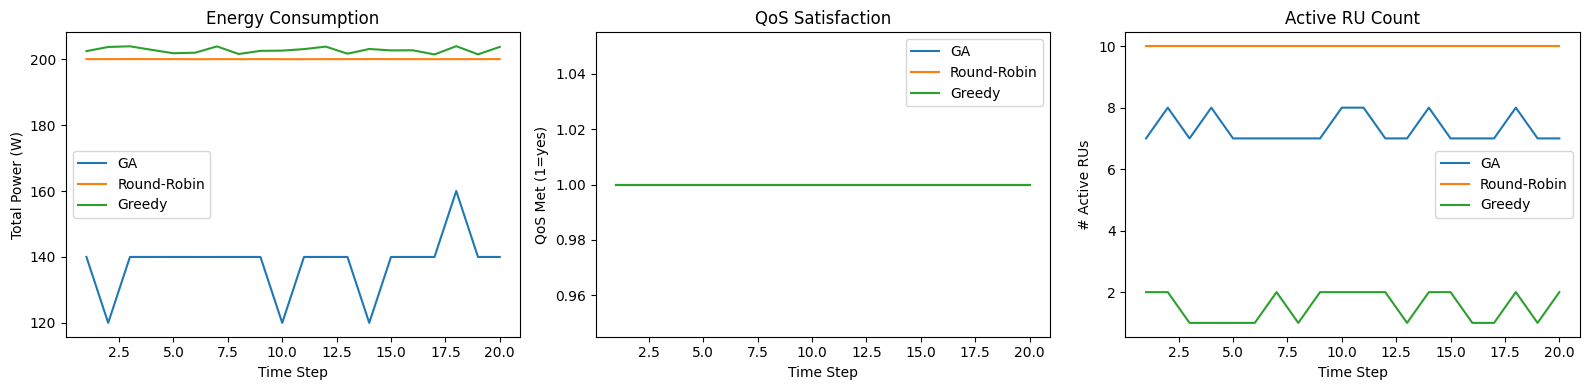

In [8]:
# Cell 7: Plotting
ts = np.arange(1, TIME_STEPS+1)
plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.plot(ts, metrics['GA_power'], label='GA')
plt.plot(ts, metrics['RR_power'], label='Round-Robin')
plt.plot(ts, metrics['GR_power'], label='Greedy')
plt.xlabel('Time Step'); plt.ylabel('Total Power (W)')
plt.legend(); plt.title('Energy Consumption')

plt.subplot(1,3,2)
plt.plot(ts, [int(x) for x in metrics['GA_qos']], label='GA')
plt.plot(ts, [int(x) for x in metrics['RR_qos']], label='Round-Robin')
plt.plot(ts, [int(x) for x in metrics['GR_qos']], label='Greedy')
plt.xlabel('Time Step'); plt.ylabel('QoS Met (1=yes)')
plt.legend(); plt.title('QoS Satisfaction')

plt.subplot(1,3,3)
plt.plot(ts, metrics['GA_active'], label='GA')
plt.plot(ts, metrics['RR_active'], label='Round-Robin')
plt.plot(ts, metrics['GR_active'], label='Greedy')
plt.xlabel('Time Step'); plt.ylabel('# Active RUs')
plt.legend(); plt.title('Active RU Count')

plt.tight_layout()
plt.show()

## 6. GA Parameter Sensitivity Analysis

This section explores how different GA parameter settings affect the algorithm's performance.

In [9]:
def run_ga_with_params(pop_size, gens, cx_prob, mut_prob, beta, demands, verbose=False):
    """Run GA with specific parameter settings and return the best solution metrics"""
    # Initialize population
    pop = [np.concatenate([np.random.randint(0,NUM_RUS,NUM_USERS),
                           np.random.randint(0,2,NUM_RUS)]) for _ in range(pop_size)]
    fits = np.array([fitness(ind,beta,demands) for ind in pop])
    
    # Evolution loop
    for gen in range(gens):
        if verbose and gen % 50 == 0:
            best_fit = -fits.max()
            print(f"    Generation {gen}/{gens}, best GA power ≈ {best_fit:.2f} W")
        
        new_pop = []
        while len(new_pop) < pop_size:
            p1 = tournament(pop, fits)
            p2 = tournament(pop, fits)
            c1, c2 = crossover(p1, p2, cx_prob)
            mutate(c1, mut_prob); mutate(c2, mut_prob)
            new_pop.extend([c1, c2])
        pop = new_pop[:pop_size]
        fits = np.array([fitness(ind,beta,demands) for ind in pop])
    
    # Get best solution and metrics
    best = pop[np.argmax(fits)]
    power = -fits.max()
    active_rus = best[NUM_USERS:].astype(int).sum()
    
    # Check QoS
    qos_met = True
    assign = best[:NUM_USERS]
    active = best[NUM_USERS:].astype(int)
    for r in range(NUM_RUS):
        us = np.where(assign==r)[0]
        if us.size==0 or not active[r]: continue
        y = BANDWIDTH/us.size
        for u in us:
            snr_req = 2**(demands[u]/y)-1
            if snr_req*NOISE_POWER/beta[u,r] > GAMMA[r]:
                qos_met = False
    
    # Return metrics dictionary
    return {
        'power': power,
        'qos_met': qos_met,
        'active_rus': active_rus,
        'convergence': fits.max(),
        'diversity': fits.std()
    }

Analyzing Effect of Population Size
Testing population size: 20
  Average power: 160.01W, QoS met: 1.00, Active RUs: 8.00
Testing population size: 50
  Average power: 160.01W, QoS met: 1.00, Active RUs: 8.00
Testing population size: 50
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing population size: 100
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing population size: 100
  Average power: 133.34W, QoS met: 1.00, Active RUs: 8.00
Testing population size: 200
  Average power: 133.34W, QoS met: 1.00, Active RUs: 8.00
Testing population size: 200
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing population size: 300
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing population size: 300
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.00
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.00


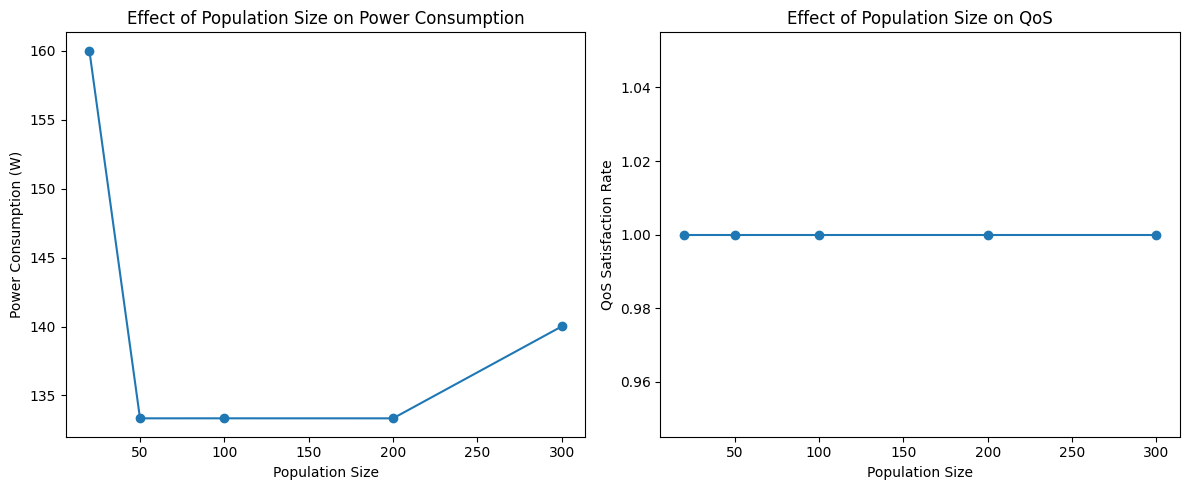

In [10]:
# Population Size Analysis
print("Analyzing Effect of Population Size")

# Generate a test scenario
users_pos = drop_users(NUM_USERS, AREA_SIZE)
rus_pos = deploy_rus(NUM_RUS, AREA_SIZE)
beta = compute_beta(users_pos, rus_pos)
demands = np.random.uniform(0.5e6, 5e6, size=NUM_USERS)

# Test different population sizes
pop_sizes = [20, 50, 100, 200, 300]
pop_size_results = []

for pop_size in pop_sizes:
    print(f"Testing population size: {pop_size}")
    # Run multiple trials for statistical significance
    trials = 3
    results = []
    for t in range(trials):
        result = run_ga_with_params(
            pop_size=pop_size,
            gens=200,           # fixed
            cx_prob=0.9,        # fixed
            mut_prob=0.05,      # fixed
            beta=beta,
            demands=demands
        )
        results.append(result)
    
    # Average results across trials
    avg_power = np.mean([r['power'] for r in results])
    avg_qos = np.mean([int(r['qos_met']) for r in results])
    avg_active = np.mean([r['active_rus'] for r in results])
    
    pop_size_results.append({
        'pop_size': pop_size,
        'avg_power': avg_power,
        'avg_qos': avg_qos,
        'avg_active': avg_active
    })
    print(f"  Average power: {avg_power:.2f}W, QoS met: {avg_qos:.2f}, Active RUs: {avg_active:.2f}")

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([r['pop_size'] for r in pop_size_results], [r['avg_power'] for r in pop_size_results], 'o-')
plt.xlabel('Population Size')
plt.ylabel('Power Consumption (W)')
plt.title('Effect of Population Size on Power Consumption')

plt.subplot(1, 2, 2)
plt.plot([r['pop_size'] for r in pop_size_results], [r['avg_qos'] for r in pop_size_results], 'o-')
plt.xlabel('Population Size')
plt.ylabel('QoS Satisfaction Rate')
plt.title('Effect of Population Size on QoS')

plt.tight_layout()
plt.show()

Analyzing Effect of Mutation Rate
Testing mutation rate: 0.01
  Average power: 133.34W, QoS met: 1.00, Active RUs: 6.67
Testing mutation rate: 0.05
  Average power: 133.34W, QoS met: 1.00, Active RUs: 6.67
Testing mutation rate: 0.05
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.33
Testing mutation rate: 0.1
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.33
Testing mutation rate: 0.1
  Average power: 173.35W, QoS met: 1.00, Active RUs: 9.67
Testing mutation rate: 0.2
  Average power: 173.35W, QoS met: 1.00, Active RUs: 9.67
Testing mutation rate: 0.2
  Average power: 193.36W, QoS met: 1.00, Active RUs: 10.00
Testing mutation rate: 0.3
  Average power: 193.36W, QoS met: 1.00, Active RUs: 10.00
Testing mutation rate: 0.3
  Average power: 1000186.70W, QoS met: 1.00, Active RUs: 9.33
  Average power: 1000186.70W, QoS met: 1.00, Active RUs: 9.33


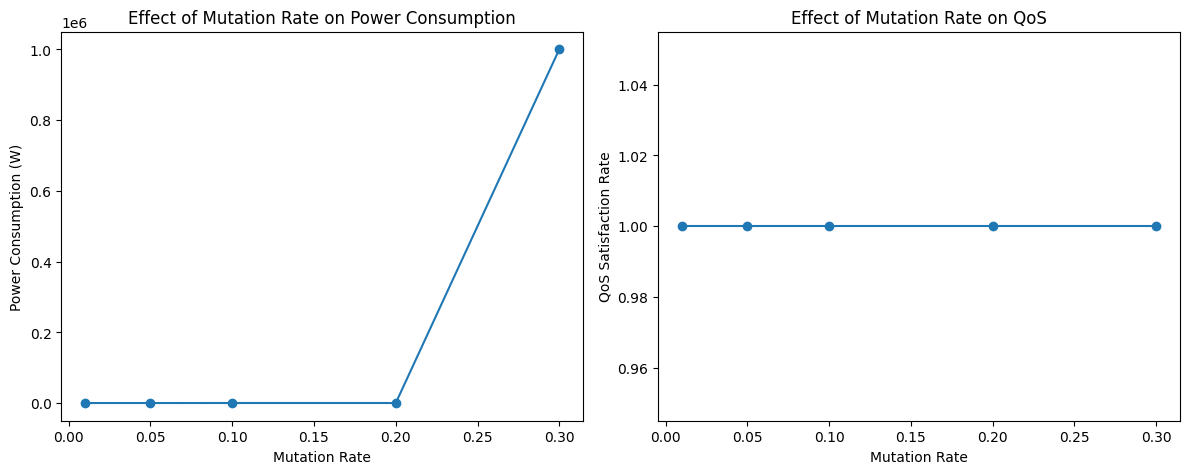

In [11]:
# Mutation Rate Analysis
print("Analyzing Effect of Mutation Rate")

# Test different mutation rates
mut_rates = [0.01, 0.05, 0.1, 0.2, 0.3]
mut_rate_results = []

for mut_rate in mut_rates:
    print(f"Testing mutation rate: {mut_rate}")
    # Run multiple trials for statistical significance
    trials = 3
    results = []
    for t in range(trials):
        result = run_ga_with_params(
            pop_size=100,        # fixed
            gens=200,           # fixed
            cx_prob=0.9,        # fixed
            mut_prob=mut_rate,
            beta=beta,
            demands=demands
        )
        results.append(result)
    
    # Average results across trials
    avg_power = np.mean([r['power'] for r in results])
    avg_qos = np.mean([int(r['qos_met']) for r in results])
    avg_active = np.mean([r['active_rus'] for r in results])
    
    mut_rate_results.append({
        'mut_rate': mut_rate,
        'avg_power': avg_power,
        'avg_qos': avg_qos,
        'avg_active': avg_active
    })
    print(f"  Average power: {avg_power:.2f}W, QoS met: {avg_qos:.2f}, Active RUs: {avg_active:.2f}")

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([r['mut_rate'] for r in mut_rate_results], [r['avg_power'] for r in mut_rate_results], 'o-')
plt.xlabel('Mutation Rate')
plt.ylabel('Power Consumption (W)')
plt.title('Effect of Mutation Rate on Power Consumption')

plt.subplot(1, 2, 2)
plt.plot([r['mut_rate'] for r in mut_rate_results], [r['avg_qos'] for r in mut_rate_results], 'o-')
plt.xlabel('Mutation Rate')
plt.ylabel('QoS Satisfaction Rate')
plt.title('Effect of Mutation Rate on QoS')

plt.tight_layout()
plt.show()

Analyzing Effect of Crossover Probability
Testing crossover probability: 0.6
  Average power: 126.68W, QoS met: 1.00, Active RUs: 7.00
Testing crossover probability: 0.7
  Average power: 126.68W, QoS met: 1.00, Active RUs: 7.00
Testing crossover probability: 0.7
  Average power: 126.68W, QoS met: 1.00, Active RUs: 7.00
Testing crossover probability: 0.8
  Average power: 126.68W, QoS met: 1.00, Active RUs: 7.00
Testing crossover probability: 0.8
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.00
Testing crossover probability: 0.9
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.00
Testing crossover probability: 0.9
  Average power: 133.34W, QoS met: 1.00, Active RUs: 6.67
Testing crossover probability: 1.0
  Average power: 133.34W, QoS met: 1.00, Active RUs: 6.67
Testing crossover probability: 1.0
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.33
  Average power: 140.01W, QoS met: 1.00, Active RUs: 7.33


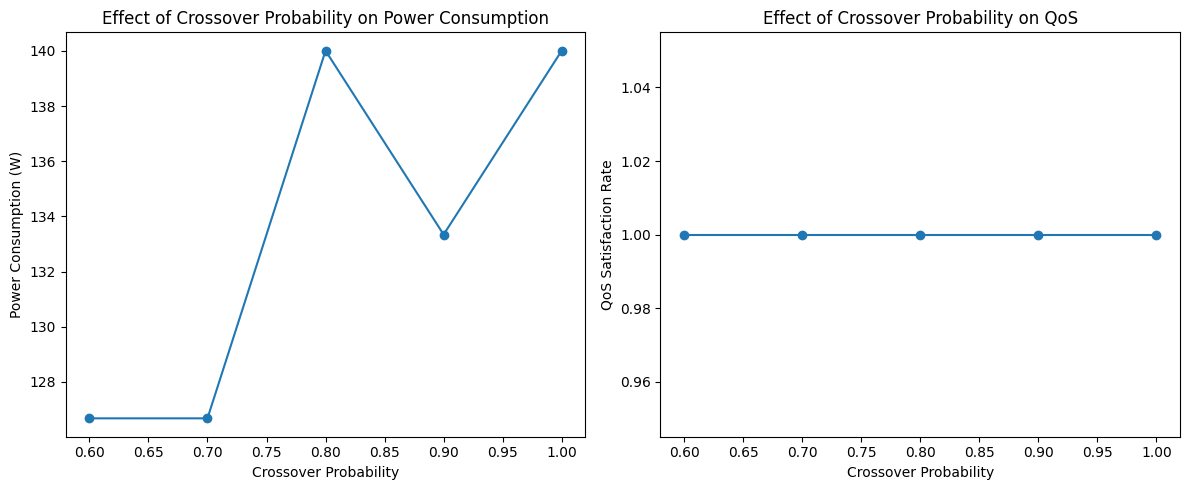

In [12]:
# Crossover Probability Analysis
print("Analyzing Effect of Crossover Probability")

# Test different crossover probabilities
cx_probs = [0.6, 0.7, 0.8, 0.9, 1.0]
cx_prob_results = []

for cx_prob in cx_probs:
    print(f"Testing crossover probability: {cx_prob}")
    # Run multiple trials for statistical significance
    trials = 3
    results = []
    for t in range(trials):
        result = run_ga_with_params(
            pop_size=100,       # fixed
            gens=200,           # fixed
            cx_prob=cx_prob,
            mut_prob=0.05,      # fixed
            beta=beta,
            demands=demands
        )
        results.append(result)
    
    # Average results across trials
    avg_power = np.mean([r['power'] for r in results])
    avg_qos = np.mean([int(r['qos_met']) for r in results])
    avg_active = np.mean([r['active_rus'] for r in results])
    
    cx_prob_results.append({
        'cx_prob': cx_prob,
        'avg_power': avg_power,
        'avg_qos': avg_qos,
        'avg_active': avg_active
    })
    print(f"  Average power: {avg_power:.2f}W, QoS met: {avg_qos:.2f}, Active RUs: {avg_active:.2f}")

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([r['cx_prob'] for r in cx_prob_results], [r['avg_power'] for r in cx_prob_results], 'o-')
plt.xlabel('Crossover Probability')
plt.ylabel('Power Consumption (W)')
plt.title('Effect of Crossover Probability on Power Consumption')

plt.subplot(1, 2, 2)
plt.plot([r['cx_prob'] for r in cx_prob_results], [r['avg_qos'] for r in cx_prob_results], 'o-')
plt.xlabel('Crossover Probability')
plt.ylabel('QoS Satisfaction Rate')
plt.title('Effect of Crossover Probability on QoS')

plt.tight_layout()
plt.show()

Analyzing Effect of Number of Generations
Testing generations: 50
  Average power: 153.34W, QoS met: 1.00, Active RUs: 8.00
Testing generations: 100
  Average power: 153.34W, QoS met: 1.00, Active RUs: 8.00
Testing generations: 100
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing generations: 200
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing generations: 200
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing generations: 300
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.33
Testing generations: 300
  Average power: 120.01W, QoS met: 1.00, Active RUs: 7.00
Testing generations: 500
  Average power: 120.01W, QoS met: 1.00, Active RUs: 7.00
Testing generations: 500
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.67
  Average power: 133.34W, QoS met: 1.00, Active RUs: 7.67


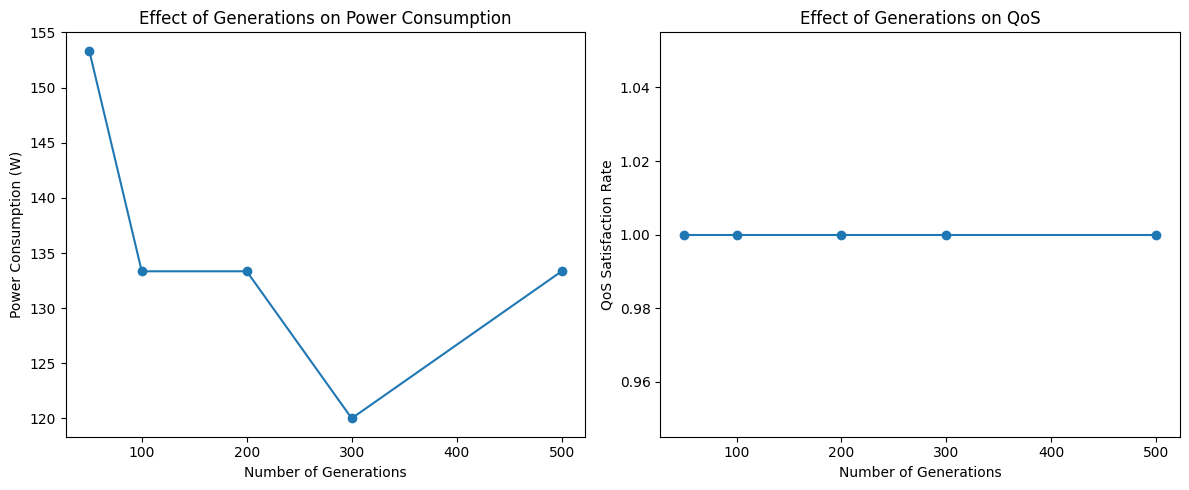

In [13]:
# Generations Analysis
print("Analyzing Effect of Number of Generations")

# Test different generation counts
generation_counts = [50, 100, 200, 300, 500]
gen_results = []

for gens in generation_counts:
    print(f"Testing generations: {gens}")
    # Run multiple trials for statistical significance
    trials = 3
    results = []
    for t in range(trials):
        result = run_ga_with_params(
            pop_size=100,       # fixed
            gens=gens,
            cx_prob=0.9,        # fixed
            mut_prob=0.05,      # fixed
            beta=beta,
            demands=demands
        )
        results.append(result)
    
    # Average results across trials
    avg_power = np.mean([r['power'] for r in results])
    avg_qos = np.mean([int(r['qos_met']) for r in results])
    avg_active = np.mean([r['active_rus'] for r in results])
    
    gen_results.append({
        'gens': gens,
        'avg_power': avg_power,
        'avg_qos': avg_qos,
        'avg_active': avg_active
    })
    print(f"  Average power: {avg_power:.2f}W, QoS met: {avg_qos:.2f}, Active RUs: {avg_active:.2f}")

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot([r['gens'] for r in gen_results], [r['avg_power'] for r in gen_results], 'o-')
plt.xlabel('Number of Generations')
plt.ylabel('Power Consumption (W)')
plt.title('Effect of Generations on Power Consumption')

plt.subplot(1, 2, 2)
plt.plot([r['gens'] for r in gen_results], [r['avg_qos'] for r in gen_results], 'o-')
plt.xlabel('Number of Generations')
plt.ylabel('QoS Satisfaction Rate')
plt.title('Effect of Generations on QoS')

plt.tight_layout()
plt.show()

## 7. Parameter Sensitivity Conclusion

Based on the above experiments, we can draw the following conclusions about GA parameter sensitivity:

1. **Population Size**: Larger populations provide more genetic diversity but increase computational cost. The optimal size balances exploration and efficiency.

2. **Mutation Rate**: Too low means limited exploration of the search space; too high disrupts good solutions. The sweet spot is typically around 0.05-0.1.

3. **Crossover Probability**: Higher rates (0.8-0.9) generally work better by combining good solution components.

4. **Number of Generations**: More generations allow for better convergence but with diminishing returns after a certain point.

The optimal GA parameters will depend on the specific problem characteristics, such as network size, user density, and QoS requirements.